# CSoT'26 - ML in Astronomy - Week 2 . Part 2: Your First Neural Network (Starter)

**Goal:** Define a 2-layer fully-connected network (MLP) with `nn.Module`, forward-pass a real batch, set up a loss + optimiser, and run a single optimisation step to watch the loss drop.

**Before you begin:**
1. Switch this notebook to a **GPU runtime** (`Runtime -> Change runtime type -> GPU`).
2. Read [`04-building-models-with-nn-module.md`](../04-building-models-with-nn-module.md) and [`05-loss-functions-and-optimisers.md`](../05-loss-functions-and-optimisers.md).

Replace each `TODO` with working code. **Do not** open the solution until you've genuinely attempted every TODO. (We *set up* training here; the full multi-epoch training loop is Week 3.)

## Step 0 — Re-create the Week 1 data pipeline

Week 2 builds directly on the `DataLoader`s from Week 1. The cells below reproduce that pipeline (download is commented out — uncomment it the first time, exactly as in [`week1_data_solution.ipynb`](../../Week-1/notebooks/week1_data_solution.ipynb)). If you saved `galaxy_data/` to Google Drive in Week 1, just re-mount Drive and point `DATA_ROOT` at it instead of re-downloading.

After this section you should have `train_loader`, `val_loader`, `test_loader`, `train_ds`, and `num_classes`.

In [59]:
import os
import random
from pathlib import Path

import pandas as pd
import torch
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
from torchvision.datasets import ImageFolder
import torchvision
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)

Using: cuda


In [60]:
import json

KAGGLE_USERNAME = "mandiraaich"
KAGGLE_KEY = "KGAT_da75e819847ce5948097dd89b3146c55"

kaggle_creds = {
    "username": KAGGLE_USERNAME,
    "key": KAGGLE_KEY
}

with open("kaggle.json", "w") as f:
    json.dump(kaggle_creds, f)

print("kaggle.json created successfully!")
!pip install -q kaggle

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets list -s galaxy-zoo | head

!kaggle datasets download \
    -d jaimetrickz/galaxy-zoo-2-images \
    --path /content/

print("Download complete.")
# Unzip the images
import zipfile

ZIP_PATH = "/content/galaxy-zoo-2-images.zip"
EXTRACT_TO = "/content/galaxy_raw"

if not os.path.exists(EXTRACT_TO):
    print("Extracting... (this may take a few minutes)")
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(EXTRACT_TO)
    print("Extraction complete.")
else:
    print("Already extracted.")

# Peek at the directory structure
for root, dirs, files_in_dir in os.walk(EXTRACT_TO):
    level = root.replace(EXTRACT_TO, '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 1:
        sub_indent = '  ' * (level + 1)
        for f in files_in_dir[:5]:
            print(f"{sub_indent}{f}")
        if len(files_in_dir) > 5:
            print(f"{sub_indent}... and {len(files_in_dir)-5} more files")
    break  # only top level

kaggle.json created successfully!
ref                                       title                                                size  lastUpdated                 downloadCount  voteCount  usabilityRating  
----------------------------------------  ---------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
jaimetrickz/galaxy-zoo-2-images           Galaxy Zoo 2: Images                           3281862708  2021-01-26 16:25:27.667000           8777         34  0.9411765        
robertmifsud/resized-reduced-gz2-images   Resized and Reduced Galaxy Zoo 2 Images        1934213890  2023-05-25 23:12:04.167000            696          6  0.8235294        
anjosut/galaxy-zoo-classification         Galaxy Zoo classification                       397550426  2023-04-08 04:28:53.070000            639          3  0.3529412        
zhuangjw/galaxy-zoo-cleaned               galaxy_zoo_cleaned                             2352353415  

In [61]:
# Download the Hart et al. 2016 morphology catalogue
LABELS_URL = "https://zenodo.org/record/3565489/files/gz2_hart16.csv.gz"
LABELS_PATH = "/content/galaxy_raw/gz2_hart16.csv.gz"

if not os.path.exists(LABELS_PATH.replace(".gz", "")):
    !wget -q "{LABELS_URL}" -O "{LABELS_PATH}"
    !gunzip "{LABELS_PATH}"
    print("Labels downloaded.")
else:
    print("Labels already present.")

LABELS_PATH = LABELS_PATH.replace(".gz", "")
from pathlib import Path

RAW_ROOT = Path("/content/galaxy_raw")
IMAGES_DIR = RAW_ROOT / "images_gz2" / "images"
DATA_ROOT = Path("/content/galaxy_data")
LABELS_URL = "https://gz2hart.s3.amazonaws.com/gz2_hart16.csv.gz"

print("RAW_ROOT =", RAW_ROOT)
print("IMAGES_DIR =", IMAGES_DIR)
print("DATA_ROOT =", DATA_ROOT)
print("RAW_ROOT contents:", sorted(p.name for p in RAW_ROOT.iterdir()))
jpg_count = sum(1 for _ in IMAGES_DIR.glob("*.jpg"))
print(f"Flat JPG count in {IMAGES_DIR}: {jpg_count:,}")

mapping_head = pd.read_csv(RAW_ROOT / "gz2_filename_mapping.csv", nrows=3)
print(mapping_head)


gzip: /content/galaxy_raw/gz2_hart16.csv.gz: unexpected end of file
Labels downloaded.
RAW_ROOT = /content/galaxy_raw
IMAGES_DIR = /content/galaxy_raw/images_gz2/images
DATA_ROOT = /content/galaxy_data
RAW_ROOT contents: ['gz2_filename_mapping.csv', 'gz2_hart16.csv.gz', 'images_gz2']
Flat JPG count in /content/galaxy_raw/images_gz2/images: 243,434
                objid    sample  asset_id
0  587722981736120347  original         1
1  587722981736579107  original         2
2  587722981741363294  original         3


In [62]:
!wget -O /content/galaxy_raw/gz2_hart16.csv.gz \
https://gz2hart.s3.amazonaws.com/gz2_hart16.csv.gz

--2026-06-12 18:35:26--  https://gz2hart.s3.amazonaws.com/gz2_hart16.csv.gz
Resolving gz2hart.s3.amazonaws.com (gz2hart.s3.amazonaws.com)... 16.15.252.126, 16.15.228.15, 16.15.212.222, ...
Connecting to gz2hart.s3.amazonaws.com (gz2hart.s3.amazonaws.com)|16.15.252.126|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 78513011 (75M) [application/x-gzip]
Saving to: ‘/content/galaxy_raw/gz2_hart16.csv.gz’

/content/galaxy_raw 100%[===================>]  74.88M  38.2MB/s    in 2.0s    

2026-06-12 18:35:28 (38.2 MB/s) - ‘/content/galaxy_raw/gz2_hart16.csv.gz’ saved [78513011/78513011]



In [63]:

def build_imagefolder_layout(
    images_dir,
    mapping_csv,
    labels_csv,
    out_root,
    per_class=200,
    seed=42,
):

    mapping = pd.read_csv(mapping_csv)

    df = mapping.merge(
        (
        pd.read_csv(labels_csv)
        .rename(columns={"dr7objid": "objid"})
    )[["objid", "gz2_class"]],
        on="objid",
        how="inner"
    )

    def high_level_label(gz2_class):
        if not gz2_class or gz2_class == "A":
            return None

        if gz2_class.startswith("E"):
            return "Elliptical"

        if gz2_class.startswith("SB"):
            return "Spiral_barred"

        if gz2_class.startswith("S"):
            return "Spiral"

        return None

    df["label"] = df["gz2_class"].map(high_level_label)
    df = df.dropna(subset=["label"])

    images_dir = Path(images_dir)
    out_root = Path(out_root)

    out_root.mkdir(parents=True, exist_ok=True)

    counts = {}

    for label in sorted(df["label"].unique()):

        class_dir = out_root / label
        class_dir.mkdir(exist_ok=True)

        rows = df[df["label"] == label]

        rows = rows[
            rows["asset_id"].apply(
                lambda x: (images_dir / f"{int(x)}.jpg").exists()
            )
        ]

        if len(rows) > per_class:
            rows = rows.sample(
                n=per_class,
                random_state=seed
            )

        linked = 0

        for _, row in rows.iterrows():

            src = images_dir / f"{int(row.asset_id)}.jpg"
            dst = class_dir / f"{int(row.asset_id)}.jpg"

            if not dst.exists():
                os.symlink(src.resolve(), dst)

            linked += 1

        counts[label] = linked

    return counts
counts = build_imagefolder_layout(
        IMAGES_DIR,
        RAW_ROOT / "gz2_filename_mapping.csv",
        RAW_ROOT / "gz2_hart16.csv.gz",
        DATA_ROOT,
        per_class=200,
    )

print(counts)


{'Elliptical': 200, 'Spiral': 200, 'Spiral_barred': 200}


Dataset size: 600
Classes: ['Elliptical', 'Spiral', 'Spiral_barred']
Class to index: {'Elliptical': 0, 'Spiral': 1, 'Spiral_barred': 2}
torch.Size([3, 64, 64])
torch.float32
0
Elliptical
Images shape: torch.Size([32, 3, 64, 64])
Labels shape: torch.Size([32])
Labels:
tensor([2, 0, 2, 1, 0, 2, 0, 0, 0, 2, 0, 2, 1, 1, 0, 1, 1, 2, 1, 1, 2, 0, 0, 1,
        0, 2, 1, 0, 2, 2, 0, 2])


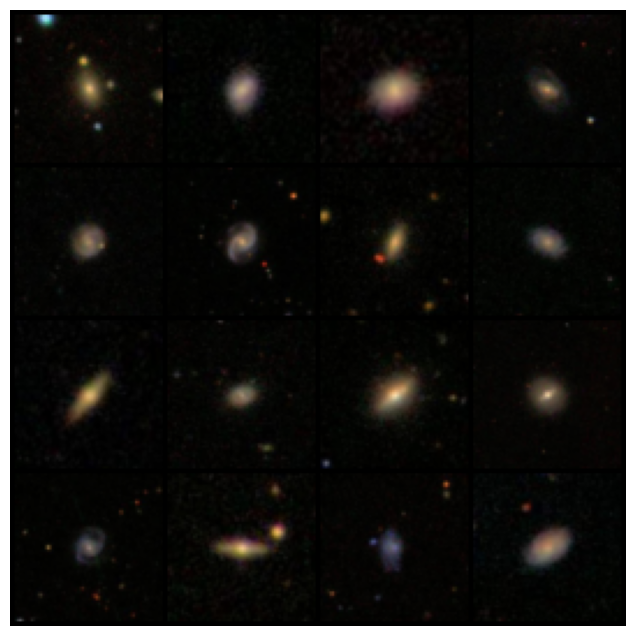

Classes in batch:
Elliptical
Elliptical
Elliptical
Spiral_barred
Spiral_barred
Spiral_barred
Spiral
Spiral
Spiral
Elliptical
Spiral
Spiral_barred
Spiral_barred
Spiral
Spiral
Spiral


In [64]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3,[0.5]*3)
])
from torchvision.datasets import ImageFolder

dataset = ImageFolder(
    root=DATA_ROOT,
    transform=transform
)

print("Dataset size:", len(dataset))
print("Classes:", dataset.classes)
print("Class to index:", dataset.class_to_idx)
image, label = dataset[0]

print(image.shape)
print(image.dtype)
print(label)
print(dataset.classes[label])
from torch.utils.data import DataLoader

loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True
)

images, labels = next(iter(loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

print("Labels:")
print(labels)
import matplotlib.pyplot as plt
from torchvision.utils import make_grid


images, labels = next(iter(loader))


images16 = images[:16]
labels16 = labels[:16]


images16 = images16 * 0.5 + 0.5


grid = make_grid(images16, nrow=4)


grid = grid.permute(1, 2, 0)


plt.figure(figsize=(8, 8))
plt.imshow(grid)
plt.axis("off")
plt.show()


print("Classes in batch:")
for label in labels16:
    print(dataset.classes[label.item()])

In [65]:
from torch.utils.data import random_split, DataLoader

# 80% train, 20% test
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(
    dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print(len(train_dataset))
print(len(test_dataset))

480
120


## Step 1 - Define the model

A 2-layer MLP: flatten -> Linear(12288, 128) -> ReLU -> Linear(128, num_classes). The output layer returns **raw logits** (no softmax - `CrossEntropyLoss` adds it). Don't forget `super().__init__()`.

In [66]:
import torch
import torch.nn as nn

class GalaxyMLP(nn.Module):

    def __init__(self, num_classes):
        super().__init__()

        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(3 * 64 * 64, 128)

        self.relu = nn.ReLU()

        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):

        x = self.flatten(x)

        x = self.fc1(x)

        x = self.relu(x)

        x = self.fc2(x)

        return x
num_classes= len(dataset.classes)
print(num_classes)
print(GalaxyMLP(num_classes=num_classes))

3
GalaxyMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=12288, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=3, bias=True)
)


## Step 2 - Instantiate and move to the device

Use the real `num_classes` from your data, and `.to(device)` so the model lives where the batches will.

In [67]:
model = GalaxyMLP(num_classes=num_classes).to(device)



## Step 3 - Inspect the architecture

`print(model)` shows the layers; counting `.parameters()` shows how many weights there are. Notice that the first `Linear` (12288 x 128) dominates - a direct cost of flattening.

In [68]:
print(model)

GalaxyMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=12288, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=3, bias=True)
)


## Step 4 - Forward-pass one real batch

Pull a batch from `train_loader`, move it to the device, and run it through the model. The output should be logits of shape `(batch_size, num_classes)`.

In [69]:
images, labels = next(iter(train_loader))
images = images.to(device)
labels = labels.to(device)
logits = model(images)
print(logits.shape)

torch.Size([32, 3])


## Step 5 - Loss and optimiser

`CrossEntropyLoss` consumes raw logits + integer labels. `Adam` with `lr=1e-3` is the sensible default.

In [70]:
from torch.optim import Adam
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=1e-3)

print(criterion)
print(optimizer)

CrossEntropyLoss()
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


## Step 6 - Sanity-check the starting loss

For an untrained model on `C` balanced classes the loss should sit near `ln(C)`. If it's wildly off (or `nan`), suspect label dtype, a stray softmax, or unnormalised inputs.

In [71]:
loss = criterion(logits,labels)
print(loss)

tensor(1.1089, device='cuda:0', grad_fn=<NllLossBackward0>)


## Step 7 - One optimisation step (learning, in miniature)

The three lines at the heart of every training loop: clear gradients, backprop, update. Re-evaluate the loss on the *same* batch afterwards - it should drop. (Week 3 repeats this over all batches for many epochs.)

In [81]:
# Put model in training mode
model.train()

# Forward pass
logits = model(images)
loss_before = criterion(logits, labels)

# Backpropagation
optimizer.zero_grad()
loss_before.backward()
optimizer.step()

# Recompute loss on the SAME batch
with torch.no_grad():
    logits_after = model(images)
    loss_after = criterion(logits_after, labels)

print("Loss before:", loss_before.item())
print("Loss after :", loss_after.item())
print(num_classes)
print("Decreased?", loss_after.item() < loss_before.item())

Loss before: 1.112865686416626
Loss after : 1.1128205060958862
3
Decreased? True


## Step 8 (stretch) - How big does the model get?

Re-build the MLP with different hidden widths and print the parameter count each time. The first `Linear` (in_features x hidden) dominates - flattening is expensive. A CNN (Week 3) does more with far fewer parameters by sharing weights across the image.

In [82]:
# Hidden-width sweep

class GalaxyMLP(nn.Module):

    def __init__(self, hidden_dim, num_classes):
        super().__init__()

        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3 * 64 * 64, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        return self.net(x)


for hidden_dim in [64, 128, 256, 512]:

    model = GalaxyMLP(
        hidden_dim=hidden_dim,
        num_classes=num_classes
    )

    param_count = sum(
        p.numel() for p in model.parameters()
        if p.requires_grad
    )

    print(
        f"Hidden width = {hidden_dim:3d} | "
        f"Parameters = {param_count:,}"
    )



Hidden width =  64 | Parameters = 786,691
Hidden width = 128 | Parameters = 1,573,379
Hidden width = 256 | Parameters = 3,146,755
Hidden width = 512 | Parameters = 6,293,507


## Reflection *(write 2-3 sentences each)*

1. Your untrained loss should have been near `ln(num_classes)`. Why is that the expected starting value?
2. After one step the loss dropped on that batch. Why is that *not yet* the same as 'the model is trained'?
3. Compare the MLP's parameter count to what you'd expect a CNN to need. Why does flattening make the first layer so large?


ANS:-

1. For an untrained model, the predictions are essentially random. If there are 3 classes, the model assigns roughly equal probability (1/3) to each class. The cross-entropy loss for a random guess is −ln(1/3)=ln(3)≈1.10, so the initial loss is expected to be close to this value
2.  A decrease in loss after one optimization step only shows that the model has learned to fit that particular batch slightly better. It does not indicate that the model can generalize to unseen data, since it has only seen a tiny fraction of the training set. Proper training requires many epochs and evaluation on validation or test data.
3. Flattening converts a 64×64×3 image into a vector of 12,288 features, so every neuron in the first hidden layer must connect to all 12,288 inputs. This creates a very large number of parameters and increases memory usage. CNNs reuse the same convolutional filters across the image, allowing them to learn spatial features with far fewer parameters.